# Portfolio Analysis and Diversification

Build on stock data: correlations, Monte Carlo efficient frontier, volatility drag, and outcome uncertainty.

## Goals

- Correlation matrix
- 10,000 random portfolios to find efficient frontier
- Volatility drag demonstration (same average return, different vol)
- Uncertainty fan and outcome distribution over 20 years


[*********************100%***********************]  4 of 4 completed


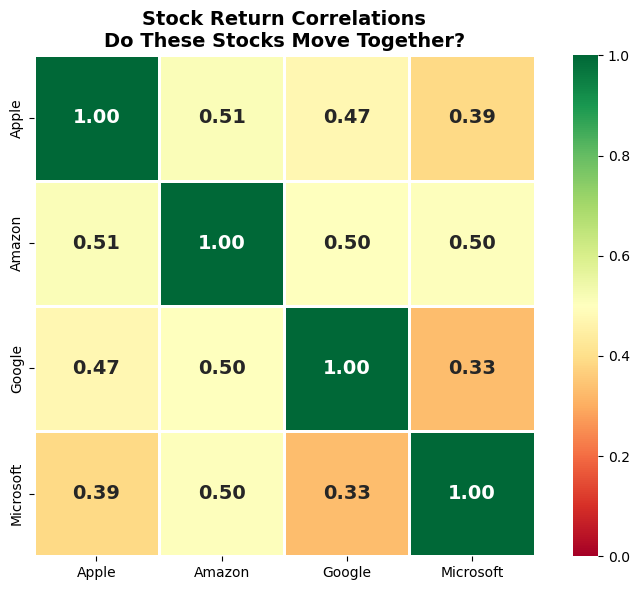

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
SEED = 42
SIM_YEARS = 20


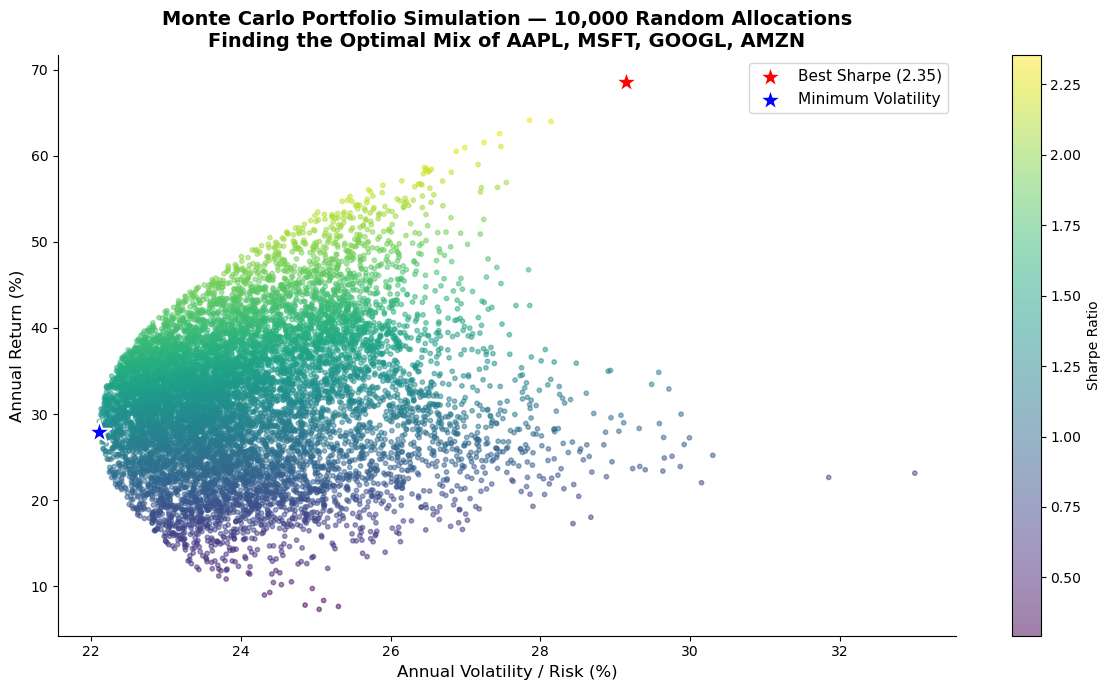


⭐ BEST RISK-ADJUSTED PORTFOLIO (Highest Sharpe Ratio):
   Apple: 0.9%
   Microsoft: 0.1%
   Google: 93.3%
   Amazon: 5.8%
   Expected Return: 68.6%
   Volatility: 29.1%

🛡️  SAFEST PORTFOLIO (Minimum Volatility):
   Apple: 24.5%
   Microsoft: 1.4%
   Google: 25.5%
   Amazon: 48.6%
   Expected Return: 27.9%
   Volatility: 22.1%


In [2]:
# Monte Carlo Portfolio Simulation
# Generate 10,000 random portfolio allocations and see which ones perform best
np.random.seed(SEED)
NUM_PORTFOLIOS = 10000

# Annualized return and covariance
annual_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

results = np.zeros((num_portfolios, 3))  # return, volatility, sharpe
weights_list = []

for i in range(num_portfolios):
    # Random weights that sum to 1 (random allocation)
    weights = np.random.random(4)
    weights /= weights.sum()
    weights_list.append(weights)
    
    # Portfolio return = weighted sum of individual returns
    port_return = np.dot(weights, annual_returns)
    
    # Portfolio volatility = uses covariance (accounts for correlations!)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    # Sharpe ratio = return per unit of risk (higher is better)
    sharpe = port_return / port_volatility
    
    results[i, 0] = port_return * 100
    results[i, 1] = port_volatility * 100
    results[i, 2] = sharpe

# Find the best portfolios
max_sharpe_idx = results[:, 2].argmax()  # Best risk-adjusted return
min_vol_idx = results[:, 1].argmin()     # Lowest risk

fig, ax = plt.subplots(figsize=(12, 7))

# Plot all 10,000 portfolios colored by Sharpe ratio
scatter = ax.scatter(results[:, 1], results[:, 0], c=results[:, 2], 
                     cmap='viridis', alpha=0.5, s=10)

# Mark the best portfolios
ax.scatter(results[max_sharpe_idx, 1], results[max_sharpe_idx, 0], 
           color='red', marker='*', s=300, zorder=5, edgecolors='white', linewidth=1.5,
           label=f'Best Sharpe ({results[max_sharpe_idx, 2]:.2f})')
ax.scatter(results[min_vol_idx, 1], results[min_vol_idx, 0],
           color='blue', marker='*', s=300, zorder=5, edgecolors='white', linewidth=1.5,
           label=f'Minimum Volatility')

plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')
ax.set_xlabel('Annual Volatility / Risk (%)', fontsize=12)
ax.set_ylabel('Annual Return (%)', fontsize=12)
ax.set_title('Monte Carlo Portfolio Simulation — 10,000 Random Allocations\nFinding the Optimal Mix of AAPL, MSFT, GOOGL, AMZN', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../data/charts/efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the optimal allocations
print("\n⭐ BEST RISK-ADJUSTED PORTFOLIO (Highest Sharpe Ratio):")
for ticker, weight in zip(tickers.values(), weights_list[max_sharpe_idx]):
    print(f"   {ticker}: {weight*100:.1f}%")
print(f"   Expected Return: {results[max_sharpe_idx, 0]:.1f}%")
print(f"   Volatility: {results[max_sharpe_idx, 1]:.1f}%")

print(f"\n🛡️  SAFEST PORTFOLIO (Minimum Volatility):")
for ticker, weight in zip(tickers.values(), weights_list[min_vol_idx]):
    print(f"   {ticker}: {weight*100:.1f}%")
print(f"   Expected Return: {results[min_vol_idx, 0]:.1f}%")
print(f"   Volatility: {results[min_vol_idx, 1]:.1f}%")

## Volatility Drag

Even with the same average return, higher volatility leads to lower compounded returns over time. This demonstrates why reducing volatility matters for long-term investing.


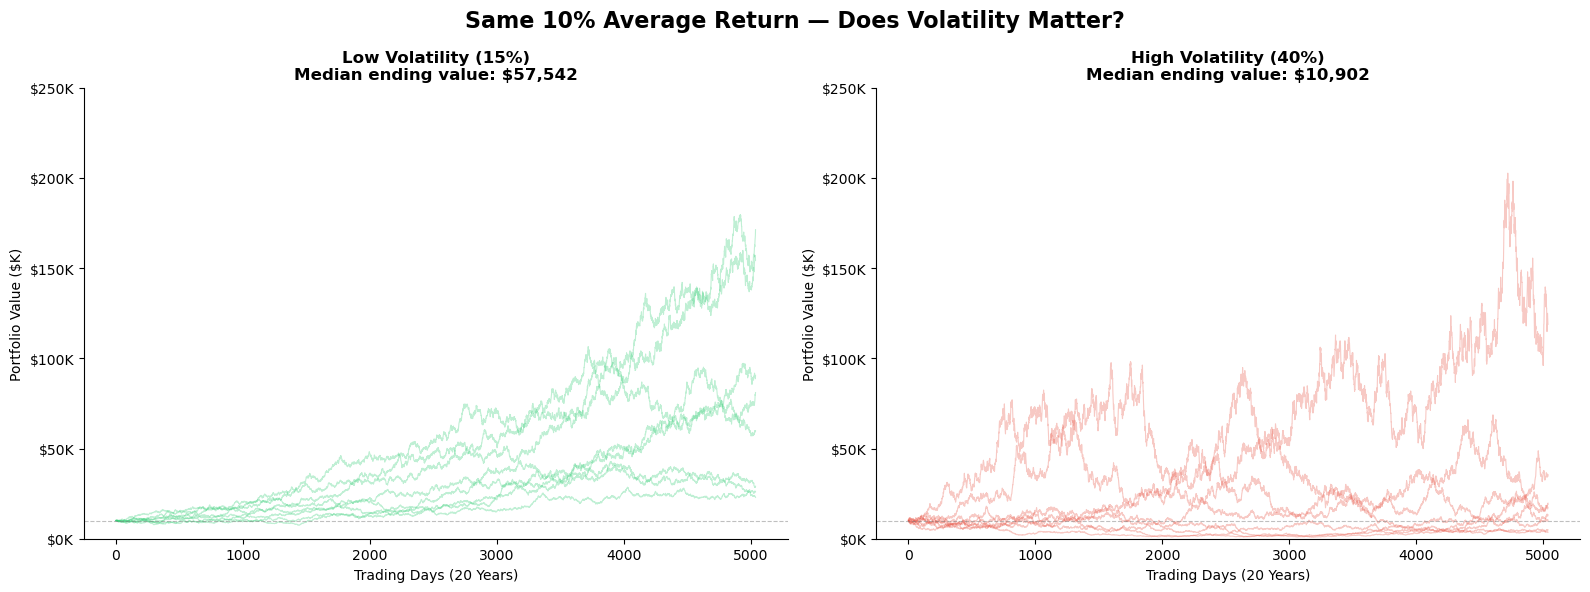


📊 AFTER 20 YEARS — 50 simulations each:

   Low Volatility (15%):
   Median ending value:  $      57,542
   Best case:            $     206,906
   Worst case:           $      10,269
   Chance of losing money: 0%

   High Volatility (40%):
   Median ending value:  $      10,902
   Best case:            $     804,821
   Worst case:           $         105
   Chance of losing money: 48%


In [3]:
# Volatility Drag — Does volatility matter if you hold long term?
# Two portfolios with the SAME average return but different volatility
np.random.seed(SEED)
years = SIM_YEARS
days = SIM_YEARS * 252

# Portfolio A: 10% average annual return, LOW volatility (15%)
# Portfolio B: 10% average annual return, HIGH volatility (40%)
daily_return_a = 0.10 / 252
daily_vol_a = 0.15 / np.sqrt(252)

daily_return_b = 0.10 / 252
daily_vol_b = 0.40 / np.sqrt(252)

# Simulate 5 different possible paths for each
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Same 10% Average Return — Does Volatility Matter?', fontsize=16, fontweight='bold')

final_values_a = []
final_values_b = []

for sim in range(50):
    # Low volatility paths
    returns_a = np.random.normal(daily_return_a, daily_vol_a, days)
    path_a = 10000 * np.cumprod(1 + returns_a)
    final_values_a.append(path_a[-1])
    if sim < 8:
        axes[0].plot(path_a / 1000, alpha=0.3, linewidth=0.8, color='#2ecc71')
    
    # High volatility paths
    returns_b = np.random.normal(daily_return_b, daily_vol_b, days)
    path_b = 10000 * np.cumprod(1 + returns_b)
    final_values_b.append(path_b[-1])
    if sim < 8:
        axes[1].plot(path_b / 1000, alpha=0.3, linewidth=0.8, color='#e74c3c')

# Format both charts the same way for comparison
for ax, title, color, finals in [
    (axes[0], 'Low Volatility (15%)', '#2ecc71', final_values_a),
    (axes[1], 'High Volatility (40%)', '#e74c3c', final_values_b)
]:
    median_final = np.median(finals)
    ax.set_title(f'{title}\nMedian ending value: ${median_final:,.0f}', fontsize=12, fontweight='bold')
    ax.axhline(y=10, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_xlabel('Trading Days (20 Years)', fontsize=10)
    ax.set_ylabel('Portfolio Value ($K)', fontsize=10)
    ax.set_ylim(0, 250)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('../data/charts/volatility_drag.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the stats
print(f"\n📊 AFTER 20 YEARS — 50 simulations each:")
print(f"\n   Low Volatility (15%):")
print(f"   Median ending value:  ${np.median(final_values_a):>12,.0f}")
print(f"   Best case:            ${np.max(final_values_a):>12,.0f}")
print(f"   Worst case:           ${np.min(final_values_a):>12,.0f}")
print(f"   Chance of losing money: {sum(1 for v in final_values_a if v < 10000)/len(final_values_a)*100:.0f}%")
print(f"\n   High Volatility (40%):")
print(f"   Median ending value:  ${np.median(final_values_b):>12,.0f}")
print(f"   Best case:            ${np.max(final_values_b):>12,.0f}")
print(f"   Worst case:           ${np.min(final_values_b):>12,.0f}")
print(f"   Chance of losing money: {sum(1 for v in final_values_b if v < 10000)/len(final_values_b)*100:.0f}%")

## Uncertainty Fan

Shows how outcomes spread over time for low vs high volatility portfolios with the same expected return. Higher vol creates wider range of possible results.


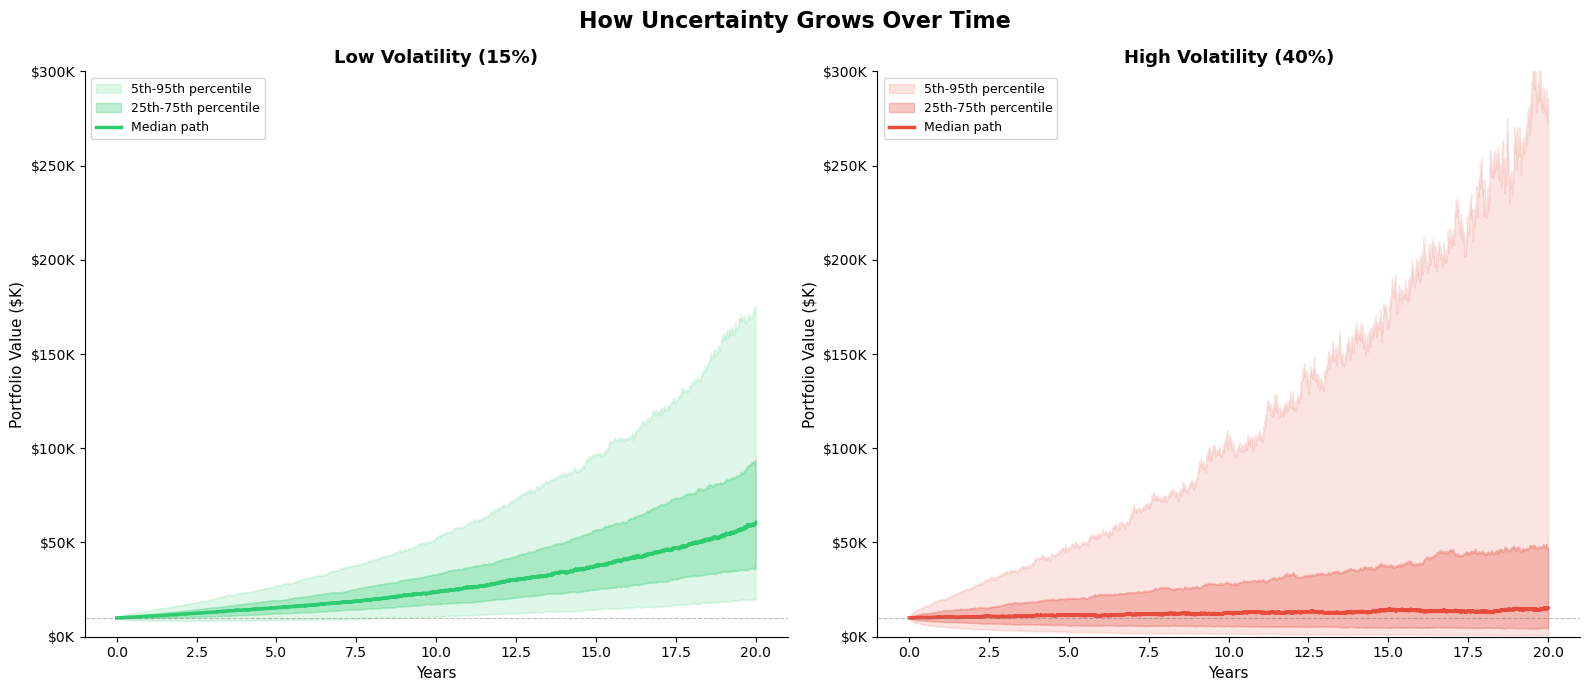

In [4]:
# How outcomes spread over time — the fan of uncertainty
np.random.seed(SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('How Uncertainty Grows Over Time', fontsize=16, fontweight='bold')

for ax, vol, color, label in [
    (axes[0], 0.15, '#2ecc71', 'Low Volatility (15%)'),
    (axes[1], 0.40, '#e74c3c', 'High Volatility (40%)')
]:
    daily_return = 0.10 / 252
    daily_vol = vol / np.sqrt(252)
    
    # Simulate 1000 paths
    all_paths = []
    for _ in range(1000):
        returns = np.random.normal(daily_return, daily_vol, 252 * 20)
        path = 10000 * np.cumprod(1 + returns)
        all_paths.append(path)
    
    all_paths = np.array(all_paths)
    
    # Calculate percentiles at each time point
    years_axis = np.arange(1, 252 * 20 + 1) / 252
    p5 = np.percentile(all_paths, 5, axis=0)
    p25 = np.percentile(all_paths, 25, axis=0)
    p50 = np.percentile(all_paths, 50, axis=0)
    p75 = np.percentile(all_paths, 75, axis=0)
    p95 = np.percentile(all_paths, 95, axis=0)
    
    # Plot the fan
    ax.fill_between(years_axis, p5/1000, p95/1000, alpha=0.15, color=color, label='5th-95th percentile')
    ax.fill_between(years_axis, p25/1000, p75/1000, alpha=0.3, color=color, label='25th-75th percentile')
    ax.plot(years_axis, p50/1000, color=color, linewidth=2.5, label='Median path')
    ax.axhline(y=10, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    
    ax.set_title(f'{label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Years', fontsize=11)
    ax.set_ylabel('Portfolio Value ($K)', fontsize=11)
    ax.set_ylim(0, 300)
    ax.legend(fontsize=9, loc='upper left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('../data/charts/uncertainty_fan.png', dpi=150, bbox_inches='tight')
plt.show()

## Outcome Distribution

Histogram of possible ending wealth for 1000 investors after 20 years. Same mean return, but volatility changes the shape of the distribution dramatically.


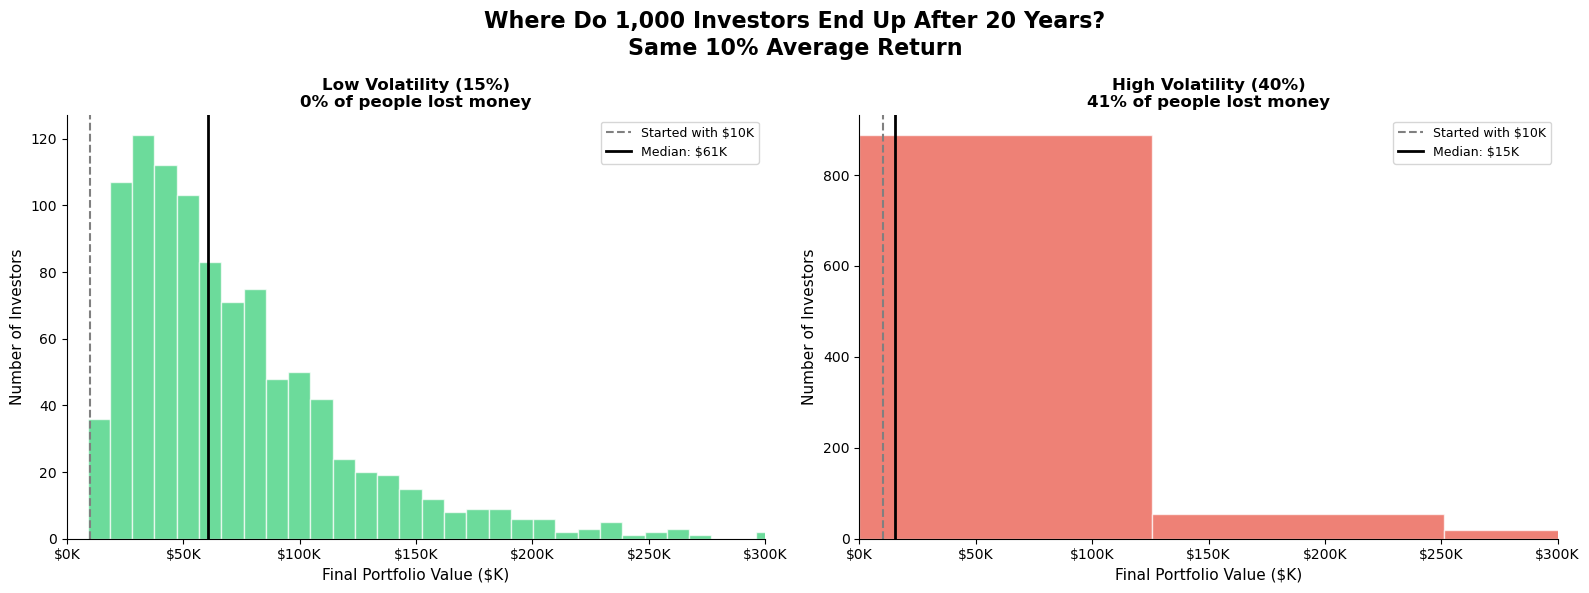

In [5]:
# Where do 1000 people actually end up after 20 years?
np.random.seed(SEED)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Where Do 1,000 Investors End Up After 20 Years?\nSame 10% Average Return', 
             fontsize=16, fontweight='bold')

for ax, vol, color, label in [
    (axes[0], 0.15, '#2ecc71', 'Low Volatility (15%)'),
    (axes[1], 0.40, '#e74c3c', 'High Volatility (40%)')
]:
    daily_return = 0.10 / 252
    daily_vol = vol / np.sqrt(252)
    
    final_values = []
    for _ in range(1000):
        returns = np.random.normal(daily_return, daily_vol, 252 * 20)
        final = 10000 * np.prod(1 + returns)
        final_values.append(final / 1000)  # Convert to thousands
    
    ax.hist(final_values, bins=50, color=color, edgecolor='white', alpha=0.7)
    ax.axvline(x=10, color='gray', linestyle='--', linewidth=1.5, label='Started with $10K')
    ax.axvline(x=np.median(final_values), color='black', linewidth=2, 
               label=f'Median: ${np.median(final_values):.0f}K')
    
    pct_lost = sum(1 for v in final_values if v < 10) / len(final_values) * 100
    ax.set_title(f'{label}\n{pct_lost:.0f}% of people lost money', fontsize=12, fontweight='bold')
    ax.set_xlabel('Final Portfolio Value ($K)', fontsize=11)
    ax.set_ylabel('Number of Investors', fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(0, 300)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:.0f}K'))

plt.tight_layout()
plt.savefig('../data/charts/outcome_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

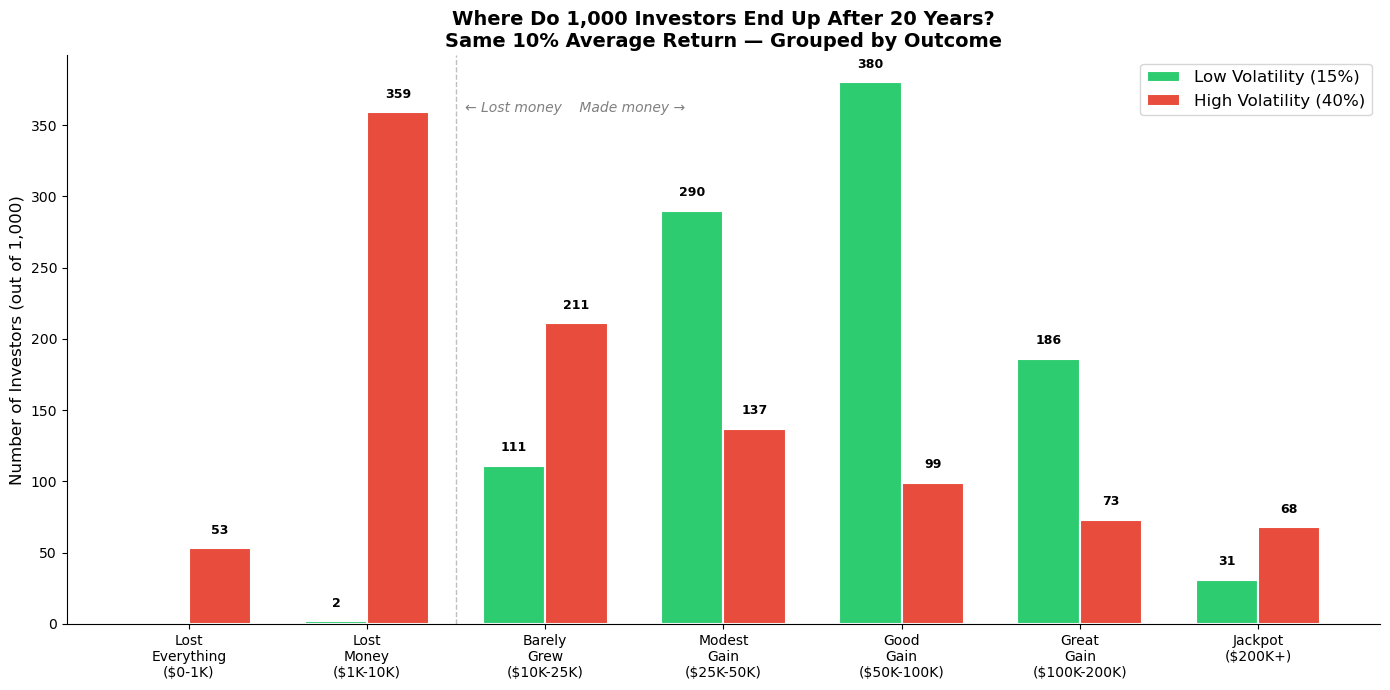

In [6]:
# Better visualization — breaking down where people actually landed
np.random.seed(SEED)

fig, ax = plt.subplots(figsize=(14, 7))

buckets = ['Lost\nEverything\n($0-1K)', 'Lost\nMoney\n($1K-10K)', 'Barely\nGrew\n($10K-25K)', 
           'Modest\nGain\n($25K-50K)', 'Good\nGain\n($50K-100K)', 'Great\nGain\n($100K-200K)', 
           'Jackpot\n($200K+)']
bucket_ranges = [(0, 1000), (1000, 10000), (10000, 25000), (25000, 50000), 
                 (50000, 100000), (100000, 200000), (200000, float('inf'))]

results = {}
for vol, label, color in [(0.15, 'Low Volatility', '#2ecc71'), (0.40, 'High Volatility', '#e74c3c')]:
    daily_return = 0.10 / 252
    daily_vol = vol / np.sqrt(252)
    
    finals = []
    for _ in range(1000):
        returns = np.random.normal(daily_return, daily_vol, 252 * 20)
        final = 10000 * np.prod(1 + returns)
        finals.append(final)
    
    counts = []
    for low, high in bucket_ranges:
        count = sum(1 for f in finals if low <= f < high)
        counts.append(count)
    results[label] = counts

x = np.arange(len(buckets))
width = 0.35

bars1 = ax.bar(x - width/2, results['Low Volatility'], width, color='#2ecc71', 
               edgecolor='white', linewidth=1.5, label='Low Volatility (15%)')
bars2 = ax.bar(x + width/2, results['High Volatility'], width, color='#e74c3c', 
               edgecolor='white', linewidth=1.5, label='High Volatility (40%)')

# Add count labels on each bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height + 8,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_ylabel('Number of Investors (out of 1,000)', fontsize=12)
ax.set_title('Where Do 1,000 Investors End Up After 20 Years?\nSame 10% Average Return — Grouped by Outcome', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(buckets, fontsize=10)
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)

# Add the "started with $10K" reference
ax.axvline(x=1.5, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.text(1.55, ax.get_ylim()[1] * 0.9, '← Lost money    Made money →', fontsize=10, 
        color='gray', style='italic')

plt.tight_layout()
plt.savefig('../data/charts/outcome_buckets.png', dpi=150, bbox_inches='tight')
plt.show()